In [14]:
# Load and explore the Egencia Analytics Case Study data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the data
df = pd.read_csv('Egencia Analytics Case Study.csv', encoding='UTF-8-SIG')

# Basic exploration
print("Dataset shape:", df.shape)
print("\Column names and types:")
print(df.dtypes)

print(df.head())

<>:13: SyntaxWarning: invalid escape sequence '\C'
<>:13: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Dhaval\AppData\Local\Temp\ipykernel_13776\561926718.py:13: SyntaxWarning: invalid escape sequence '\C'
  print("\Column names and types:")


Dataset shape: (299999, 14)
\Column names and types:
BOOKING_ID                int64
BOOKING_TYPE_NAME        object
PRODUCT_NAME             object
PLATFORM                 object
CUSTOMER_ID               int64
TRAVELER_ID               int64
BOOKING_DATE             object
TRAVEL_START             object
TRAVEL_END               object
INVOICE_DATE             object
ONLINE_PURCHASE_FLAG       bool
BOOKING_AMOUNT          float64
SAVINGS_AMOUNT          float64
TRANSACTION_COUNT         int64
dtype: object
   BOOKING_ID BOOKING_TYPE_NAME PRODUCT_NAME PLATFORM  CUSTOMER_ID  \
0   159585350           Reserve          Car  Desktop            0   
1   128623600            Cancel          Car  Desktop            0   
2    16125082           Reserve          Car   Mobile            0   
3   129001472           Reserve          Car  Desktop            0   
4    64792032           Reserve          Car  Desktop            0   

   TRAVELER_ID BOOKING_DATE TRAVEL_START  TRAVEL_END INVOICE_DAT

In [15]:
# Convert date columns and handle missing values
df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'], format='%d/%m/%Y', errors='coerce')
df['TRAVEL_START'] = pd.to_datetime(df['TRAVEL_START'], format='%d/%m/%Y', errors='coerce')
df['TRAVEL_END'] = pd.to_datetime(df['TRAVEL_END'], format='%d/%m/%Y', errors='coerce')

# Filter out cancelled partial refund refund and void bookings for customer value analysis
df = df[df['BOOKING_TYPE_NAME'].isin(['Purchase']) & df['PLATFORM'].isin(['Desktop']) & df['PRODUCT_NAME'].isin(['Air'])].copy()

#active_bookings = df[df['BOOKING_TYPE_NAME'] == 'Reserve'].copy()

active_bookings = df
print("Active bookings shape:", active_bookings.shape)
print("Date range:", active_bookings['BOOKING_DATE'].min(), "to", active_bookings['BOOKING_DATE'].max())

Active bookings shape: (91102, 14)
Date range: 2018-01-01 00:00:00 to 2018-12-31 00:00:00


In [16]:
# Calculate customer value and loyalty metrics
customer_metrics = active_bookings.groupby('CUSTOMER_ID').agg({
    'BOOKING_AMOUNT': ['sum', 'mean', 'count'],
    'BOOKING_DATE': ['min', 'max'],
    'PRODUCT_NAME': 'nunique',
    'PLATFORM': 'nunique'
}).round(2)

# Flatten column names
customer_metrics.columns = ['total_value', 'avg_booking_value', 'booking_frequency', 
                           'first_booking', 'last_booking', 'product_diversity', 'platform_diversity']

# Calculate additional loyalty metrics
customer_metrics['booking_span_days'] = (customer_metrics['last_booking'] - customer_metrics['first_booking']).dt.days
customer_metrics['recency_days'] = (active_bookings['BOOKING_DATE'].max() - customer_metrics['last_booking']).dt.days

print("Customer metrics calculated:")
print(customer_metrics.head())
print("\Metrics summary:")
print(customer_metrics.describe())

Customer metrics calculated:
             total_value  avg_booking_value  booking_frequency first_booking  \
CUSTOMER_ID                                                                    
1000           917256.65            1455.96                630    2018-01-03   
1001          6255114.58            6108.51               1024    2018-01-01   
1002          1102471.43            2149.07                513    2018-01-04   
1003          4822448.73            4562.39               1057    2018-01-02   
1004          1168076.61            2927.51                399    2018-01-04   

            last_booking  product_diversity  platform_diversity  \
CUSTOMER_ID                                                       
1000          2018-12-26                  1                   1   
1001          2018-12-31                  1                   1   
1002          2018-12-27                  1                   1   
1003          2018-12-21                  1                   1   
1004    

<>:19: SyntaxWarning: invalid escape sequence '\M'
<>:19: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Dhaval\AppData\Local\Temp\ipykernel_13776\3266749492.py:19: SyntaxWarning: invalid escape sequence '\M'
  print("\Metrics summary:")


In [17]:
# Create customer segments based on value and loyalty metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Select key metrics for segmentation
segmentation_features = ['total_value', 'booking_frequency', 'avg_booking_value', 'recency_days', 'product_diversity']
X = customer_metrics[segmentation_features].copy()

# Handle any missing values
X = X.fillna(X.median())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_metrics['segment'] = kmeans.fit_predict(X_scaled)

print("Customer segments created:")
print(customer_metrics['segment'].value_counts().sort_index())


Customer segments created:
segment
0     9
1    52
2     1
3     1
Name: count, dtype: int64


In [32]:
customer_metrics.to_csv('customer_segments.csv', index=True)

PermissionError: [Errno 13] Permission denied: 'customer_segments.csv'

In [18]:
# Analyze segment characteristics
segment_analysis = customer_metrics.groupby('segment')[segmentation_features + ['booking_span_days']].agg(['mean', 'median', 'count']).round(2)

print("Segment Analysis:")
for segment in sorted(customer_metrics['segment'].unique()):
    print(f"\=== SEGMENT {segment} ===")
    segment_data = customer_metrics[customer_metrics['segment'] == segment]
    print(f"Number of customers: {len(segment_data)}")
    print(f"Total Value - Mean: ${segment_data['total_value'].mean():,.2f}, Median: ${segment_data['total_value'].median():,.2f}")
    print(f"Booking Frequency - Mean: {segment_data['booking_frequency'].mean():.1f}, Median: {segment_data['booking_frequency'].median():.1f}")
    print(f"Avg Booking Value - Mean: ${segment_data['avg_booking_value'].mean():,.2f}, Median: ${segment_data['avg_booking_value'].median():,.2f}")
    print(f"Recency (days) - Mean: {segment_data['recency_days'].mean():.1f}, Median: {segment_data['recency_days'].median():.1f}")
    print(f"Product Diversity - Mean: {segment_data['product_diversity'].mean():.1f}")
    print(f"Booking Span (days) - Mean: {segment_data['booking_span_days'].mean():.1f}")

Segment Analysis:
\=== SEGMENT 0 ===
Number of customers: 9
Total Value - Mean: $11,196,698.86, Median: $8,399,595.60
Booking Frequency - Mean: 3225.0, Median: 1800.0
Avg Booking Value - Mean: $5,250.33, Median: $4,562.39
Recency (days) - Mean: 4.0, Median: 0.0
Product Diversity - Mean: 1.0
Booking Span (days) - Mean: 355.8
\=== SEGMENT 1 ===
Number of customers: 52
Total Value - Mean: $1,724,128.93, Median: $850,958.76
Booking Frequency - Mean: 728.8, Median: 376.5
Avg Booking Value - Mean: $2,240.15, Median: $2,141.41
Recency (days) - Mean: 10.8, Median: 4.0
Product Diversity - Mean: 1.0
Booking Span (days) - Mean: 349.3
\=== SEGMENT 2 ===
Number of customers: 1
Total Value - Mean: $48,359,019.17, Median: $48,359,019.17
Booking Frequency - Mean: 24176.0, Median: 24176.0
Avg Booking Value - Mean: $2,000.29, Median: $2,000.29
Recency (days) - Mean: 0.0, Median: 0.0
Product Diversity - Mean: 1.0
Booking Span (days) - Mean: 364.0
\=== SEGMENT 3 ===
Number of customers: 1
Total Value - Me

In [20]:
# Create meaningful segment labels and save results
segment_labels = {
    0: 'At-Risk Customers',
    1: 'Loyal Champions', 
    2: 'VIP Whale',
    3: 'High-Value Customers'
}

customer_metrics['segment_label'] = customer_metrics['segment'].map(segment_labels)

# Create summary table
segment_summary = pd.DataFrame({
    'Segment': [segment_labels[i] for i in sorted(segment_labels.keys())],
    'Count': [len(customer_metrics[customer_metrics['segment'] == i]) for i in sorted(segment_labels.keys())],
    'Avg_Total_Value': [customer_metrics[customer_metrics['segment'] == i]['total_value'].mean() for i in sorted(segment_labels.keys())],
    'Avg_Booking_Frequency': [customer_metrics[customer_metrics['segment'] == i]['booking_frequency'].mean() for i in sorted(segment_labels.keys())],
    'Avg_Recency_Days': [customer_metrics[customer_metrics['segment'] == i]['recency_days'].mean() for i in sorted(segment_labels.keys())],
    'Avg_Booking_Value': [customer_metrics[customer_metrics['segment'] == i]['avg_booking_value'].mean() for i in sorted(segment_labels.keys())]
}).round(2)

print("Customer Segmentation Summary:")
print(segment_summary)

# Save the customer segments to file
customer_segments_export = customer_metrics[['total_value', 'booking_frequency', 'avg_booking_value', 
                                           'recency_days', 'product_diversity', 'segment', 'segment_label']].copy()
#customer_segments_export.to_csv('customer_segments.csv')
print("\Customer segments saved to 'customer_segments.csv'")

Customer Segmentation Summary:
                Segment  Count  Avg_Total_Value  Avg_Booking_Frequency  \
0     At-Risk Customers      9      11196698.86                3225.00   
1       Loyal Champions     52       1724128.93                 728.85   
2             VIP Whale      1      48359019.17               24176.00   
3  High-Value Customers      1           446.94                   1.00   

   Avg_Recency_Days  Avg_Booking_Value  
0              4.00            5250.33  
1             10.77            2240.15  
2              0.00            2000.29  
3            343.00             446.94  
\Customer segments saved to 'customer_segments.csv'


<Figure size 1500x1000 with 0 Axes>

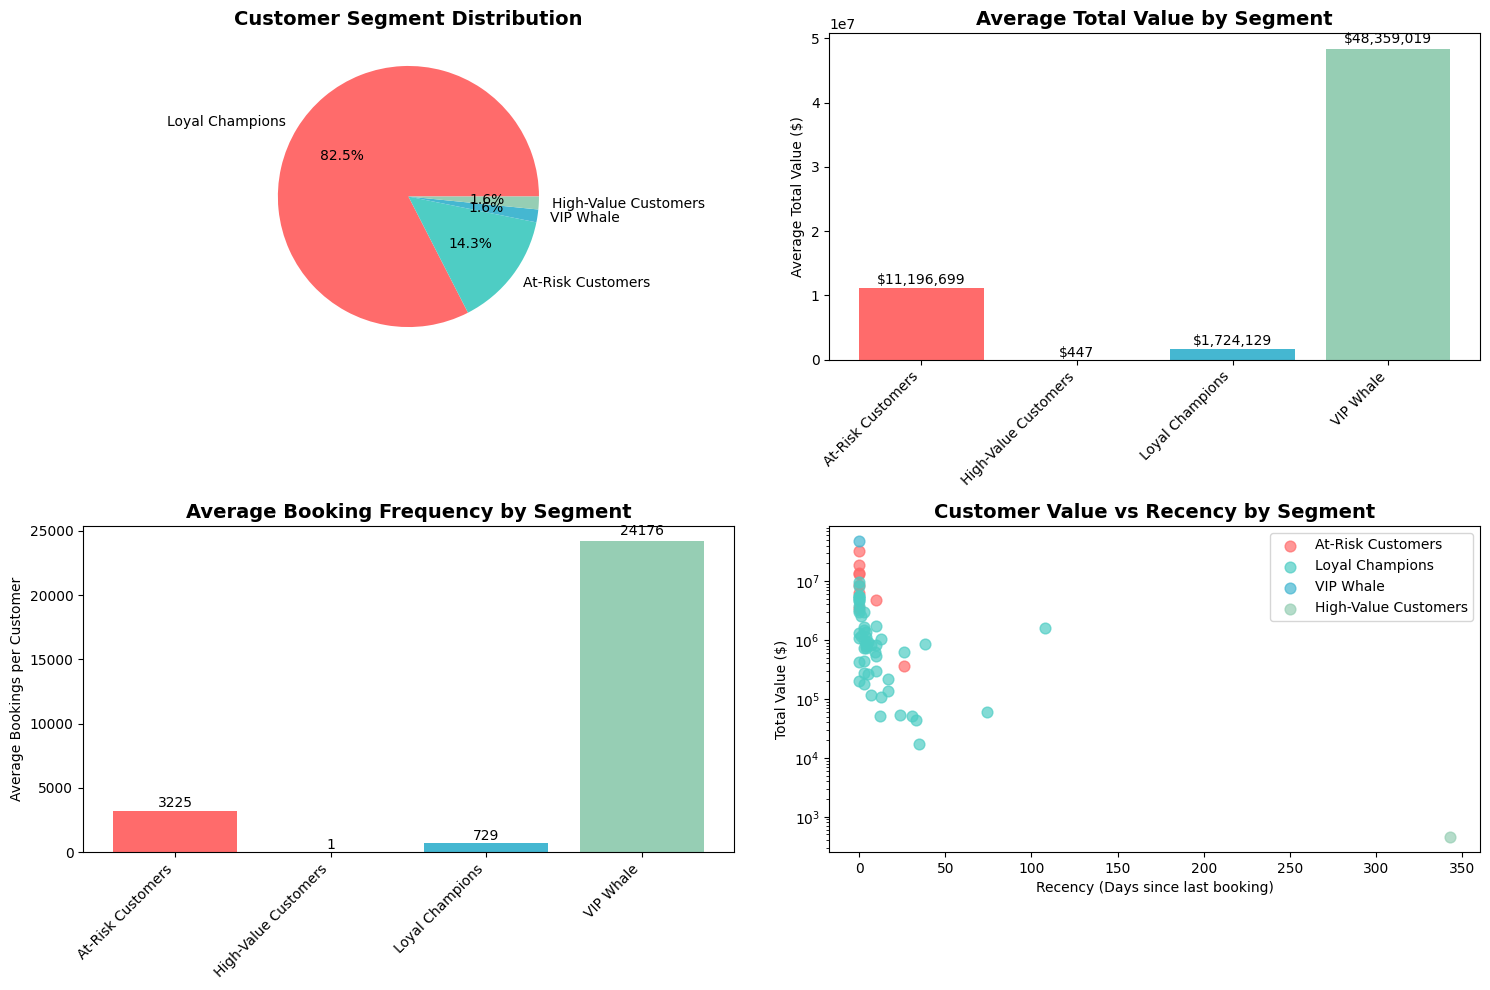

In [21]:
# Create visualization of customer segments
plt.figure(figsize=(15, 10))

# Create a 2x2 subplot layout
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Segment distribution
segment_counts = customer_metrics['segment_label'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
ax1.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors)
ax1.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

# 2. Total Value by Segment
segment_value = customer_metrics.groupby('segment_label')['total_value'].mean()
bars1 = ax2.bar(range(len(segment_value)), segment_value.values, color=colors)
ax2.set_xticks(range(len(segment_value)))
ax2.set_xticklabels(segment_value.index, rotation=45, ha='right')
ax2.set_title('Average Total Value by Segment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Average Total Value ($)')
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

# 3. Booking Frequency by Segment
segment_freq = customer_metrics.groupby('segment_label')['booking_frequency'].mean()
bars2 = ax3.bar(range(len(segment_freq)), segment_freq.values, color=colors)
ax3.set_xticks(range(len(segment_freq)))
ax3.set_xticklabels(segment_freq.index, rotation=45, ha='right')
ax3.set_title('Average Booking Frequency by Segment', fontsize=14, fontweight='bold')
ax3.set_ylabel('Average Bookings per Customer')
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.0f}', ha='center', va='bottom', fontsize=10)

# 4. Recency vs Value scatter plot
for i, (segment, color) in enumerate(zip(sorted(customer_metrics['segment'].unique()), colors)):
    segment_data = customer_metrics[customer_metrics['segment'] == segment]
    ax4.scatter(segment_data['recency_days'], segment_data['total_value'], 
               c=color, label=segment_labels[segment], alpha=0.7, s=60)

ax4.set_xlabel('Recency (Days since last booking)')
ax4.set_ylabel('Total Value ($)')
ax4.set_title('Customer Value vs Recency by Segment', fontsize=14, fontweight='bold')
ax4.legend()
ax4.set_yscale('log')

plt.tight_layout()
plt.show()



In [22]:
# Merge customer segments back to original booking data
active_bookings_with_segments = active_bookings.merge(
    customer_metrics[['segment', 'segment_label']], 
    left_on='CUSTOMER_ID', 
    right_index=True, 
    how='left'
)

# Create month-year column for aggregation
active_bookings_with_segments['booking_month'] = active_bookings_with_segments['BOOKING_DATE'].dt.to_period('M')

print("Data merged successfully")
print("Shape after merge:", active_bookings_with_segments.shape)
print("Segments in merged data:", active_bookings_with_segments['segment_label'].value_counts())
#active_bookings_with_segments.to_csv('active_bookings_with_segments.csv', index=False )

Data merged successfully
Shape after merge: (91102, 17)
Segments in merged data: segment_label
Loyal Champions         37900
At-Risk Customers       29025
VIP Whale               24176
High-Value Customers        1
Name: count, dtype: int64


In [23]:
# Aggregate monthly data by customer segment
monthly_segment_trends = active_bookings_with_segments.groupby(['booking_month', 'segment_label']).agg({
    'BOOKING_AMOUNT': 'sum',
    'BOOKING_ID': 'count'
}).reset_index()
#monthly_segment_trends.to_csv('monthly_segment_trends1.csv', index=False)
monthly_segment_trends.columns = ['booking_month', 'segment_label', 'total_booking_amount', 'transaction_count']

# Convert period to datetime for plotting
monthly_segment_trends['booking_month_dt'] = monthly_segment_trends['booking_month'].dt.to_timestamp()

print("Monthly segment trends aggregated:")
print(monthly_segment_trends.head(10))
#monthly_segment_trends.to_csv('monthly_segment_trends.csv', index=False)

Monthly segment trends aggregated:
  booking_month         segment_label  total_booking_amount  \
0       2018-01     At-Risk Customers            8601285.71   
1       2018-01  High-Value Customers                446.94   
2       2018-01       Loyal Champions            8263541.55   
3       2018-01             VIP Whale            4904397.60   
4       2018-02     At-Risk Customers            8055195.43   
5       2018-02       Loyal Champions            7354872.84   
6       2018-02             VIP Whale            5602320.17   
7       2018-03     At-Risk Customers           11109244.97   
8       2018-03       Loyal Champions            9103150.16   
9       2018-03             VIP Whale            5694580.77   

   transaction_count booking_month_dt  
0               2586       2018-01-01  
1                  1       2018-01-01  
2               3602       2018-01-01  
3               2626       2018-01-01  
4               2285       2018-02-01  
5               3019       2018

<Figure size 1600x1200 with 0 Axes>

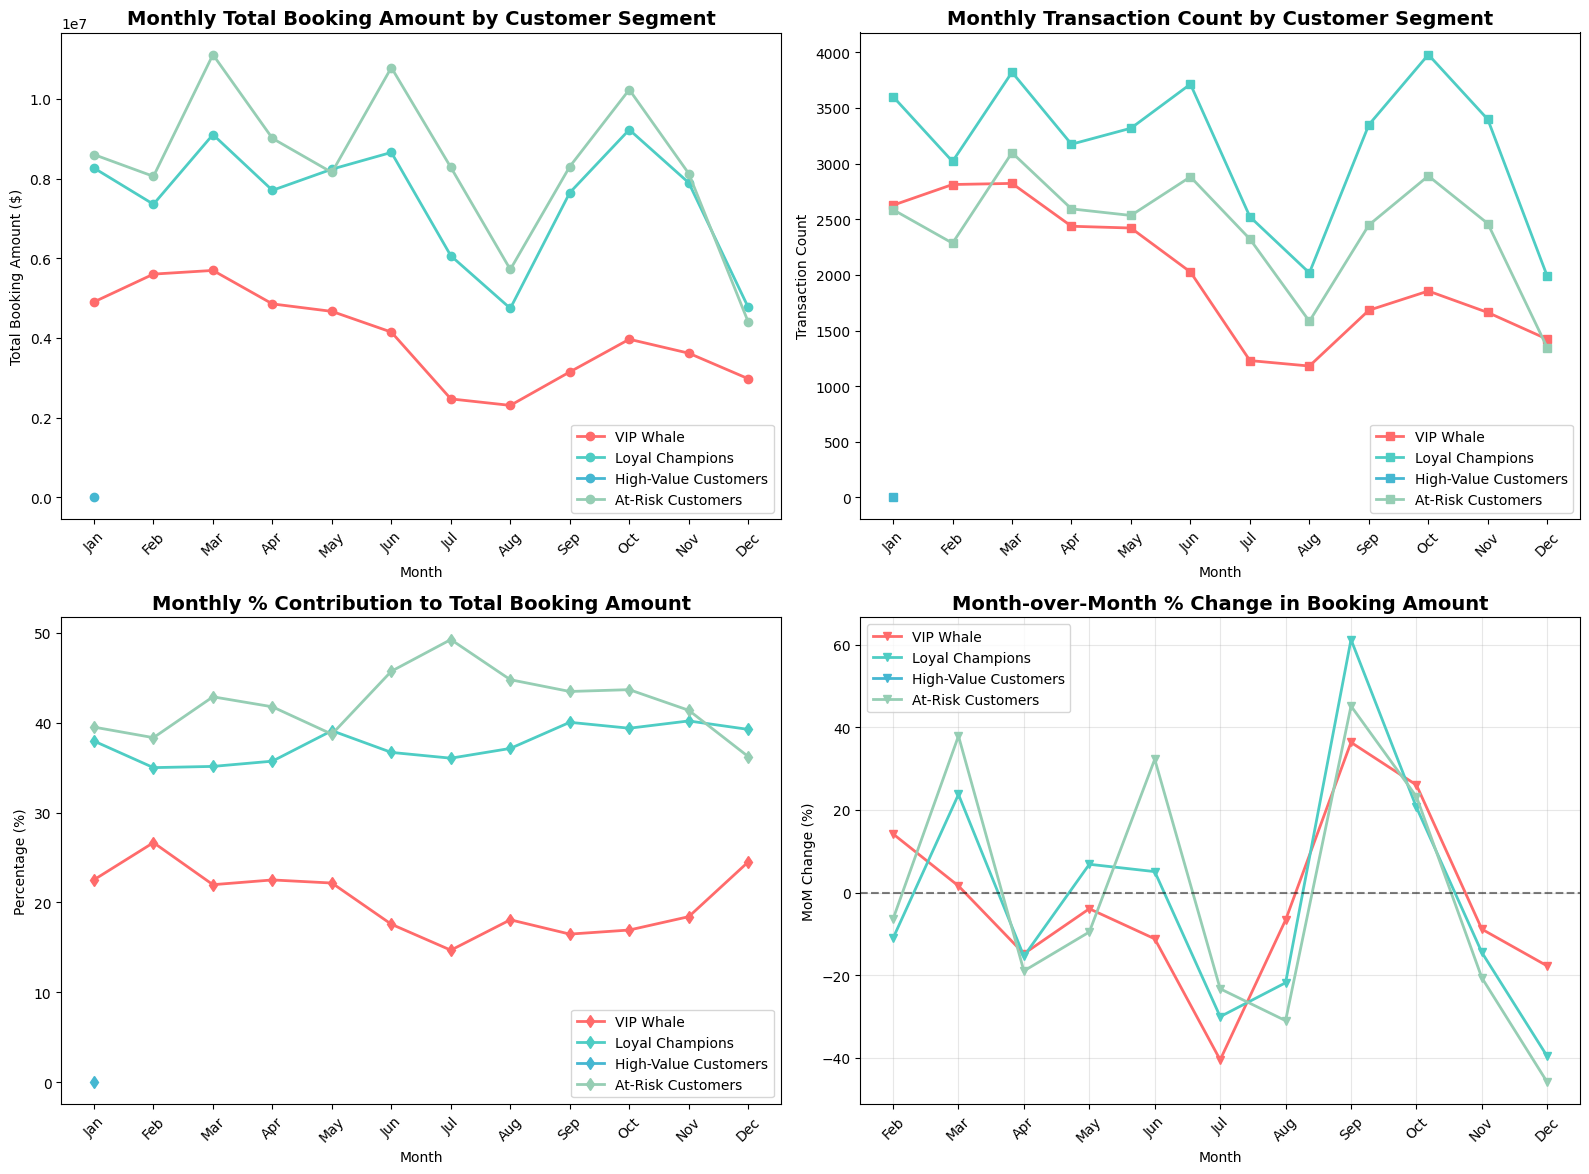

In [24]:
# Create comprehensive trending visualization
plt.figure(figsize=(16, 12))
#no grid line

# Define colors for each segment
segment_colors = {
    'VIP Whale': '#FF6B6B',
    'Loyal Champions': '#4ECDC4', 
    'High-Value Customers': '#45B7D1',
    'At-Risk Customers': '#96CEB4'
}
#segment_data['booking_month_dt'] = pd.to_datetime(segment_data['booking_month_dt'], format='%m', errors='coerce')
#segment_data['booking_month_dt'] = segment_data['booking_month_dt'].dt.strftime('%b')
# Create 2x2 subplot layout
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total Booking Amount Trends by Segment
for segment in segment_colors.keys():
    segment_data = monthly_segment_trends[monthly_segment_trends['segment_label'] == segment]
    ax1.plot(segment_data['booking_month_dt'].dt.strftime('%b'), segment_data['total_booking_amount'], 
             marker='o', linewidth=2, label=segment, color=segment_colors[segment])

ax1.set_title('Monthly Total Booking Amount by Customer Segment', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Booking Amount ($)')
ax1.legend()
ax1.grid(False)
ax1.tick_params(axis='x', rotation=45)

# 2. Transaction Count Trends by Segment
for segment in segment_colors.keys():
    segment_data = monthly_segment_trends[monthly_segment_trends['segment_label'] == segment]
    ax2.plot(segment_data['booking_month_dt'].dt.strftime('%b'), segment_data['transaction_count'], 
             marker='s', linewidth=2, label=segment, color=segment_colors[segment])

ax2.set_title('Monthly Transaction Count by Customer Segment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Transaction Count')
ax2.legend()
ax2.grid(False)
ax2.tick_params(axis='x', rotation=45)

# 3. Percentage contribution to total booking amount
monthly_totals = monthly_segment_trends.groupby('booking_month_dt')['total_booking_amount'].sum()
monthly_segment_pct = monthly_segment_trends.copy()
monthly_segment_pct['pct_contribution'] = monthly_segment_pct.apply(
    lambda row: (row['total_booking_amount'] / monthly_totals[row['booking_month_dt']]) * 100, axis=1
)

for segment in segment_colors.keys():
    segment_data = monthly_segment_pct[monthly_segment_pct['segment_label'] == segment]
    ax3.plot(segment_data['booking_month_dt'].dt.strftime('%b'), segment_data['pct_contribution'], 
             marker='d', linewidth=2, label=segment, color=segment_colors[segment])

ax3.set_title('Monthly % Contribution to Total Booking Amount', fontsize=14, fontweight='bold')
ax3.set_xlabel('Month')
ax3.set_ylabel('Percentage (%)')
ax3.legend()
ax3.grid(False)
ax3.tick_params(axis='x', rotation=45)

# 4. Month-over-month change in booking amount by segment
monthly_segment_mom = monthly_segment_trends.copy()
monthly_segment_mom['mom_change'] = monthly_segment_mom.groupby('segment_label')['total_booking_amount'].pct_change() * 100

for segment in segment_colors.keys():
    segment_data = monthly_segment_mom[monthly_segment_mom['segment_label'] == segment]
    ax4.plot(segment_data['booking_month_dt'].dt.strftime('%b'), segment_data['mom_change'], 
             marker='v', linewidth=2, label=segment, color=segment_colors[segment])

ax4.set_title('Month-over-Month % Change in Booking Amount', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('MoM Change (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [30]:
# Load and prepare the data for comprehensive analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('Egencia Analytics Case Study.csv', encoding='UTF-8-SIG')

# Convert date columns to datetime
df['BOOKING_DATE'] = pd.to_datetime(df['BOOKING_DATE'], format='%d/%m/%Y', errors='coerce')
df['TRAVEL_START'] = pd.to_datetime(df['TRAVEL_START'], format='%d/%m/%Y', errors='coerce')
df['TRAVEL_END'] = pd.to_datetime(df['TRAVEL_END'], format='%d/%m/%Y', errors='coerce')

# Calculate travel duration in days
df['TRAVEL_DURATION'] = (df['TRAVEL_END'] - df['TRAVEL_START']).dt.days

# Filter for active bookings (Reserve Purchase for Car/Hotel, Purchase Exchange for Air)
active_bookings = df[
    (
        ((df['PRODUCT_NAME'].isin(['Car', 'Hotel'])) & (df['BOOKING_TYPE_NAME'].isin(['Purchase', 'Reserve'])))
        |
        ((df['PRODUCT_NAME'] == 'Air') & (df['BOOKING_TYPE_NAME'].isin(['Purchase', 'Exchange'])))
    )
].copy()

# Create monthly periods for analysis
active_bookings['BOOKING_MONTH'] = active_bookings['BOOKING_DATE'].dt.to_period('M')

print("Dataset Overview:")
print("Total active bookings:", len(active_bookings))
print("Date range:", active_bookings['BOOKING_DATE'].min(), "to", active_bookings['BOOKING_DATE'].max())
print("Products:", active_bookings['PRODUCT_NAME'].unique())
print("Platforms:", active_bookings['PLATFORM'].unique())

Dataset Overview:
Total active bookings: 267082
Date range: 2018-01-01 00:00:00 to 2018-12-31 00:00:00
Products: ['Car' 'Hotel' 'Air']
Platforms: ['Desktop' 'Mobile' nan]


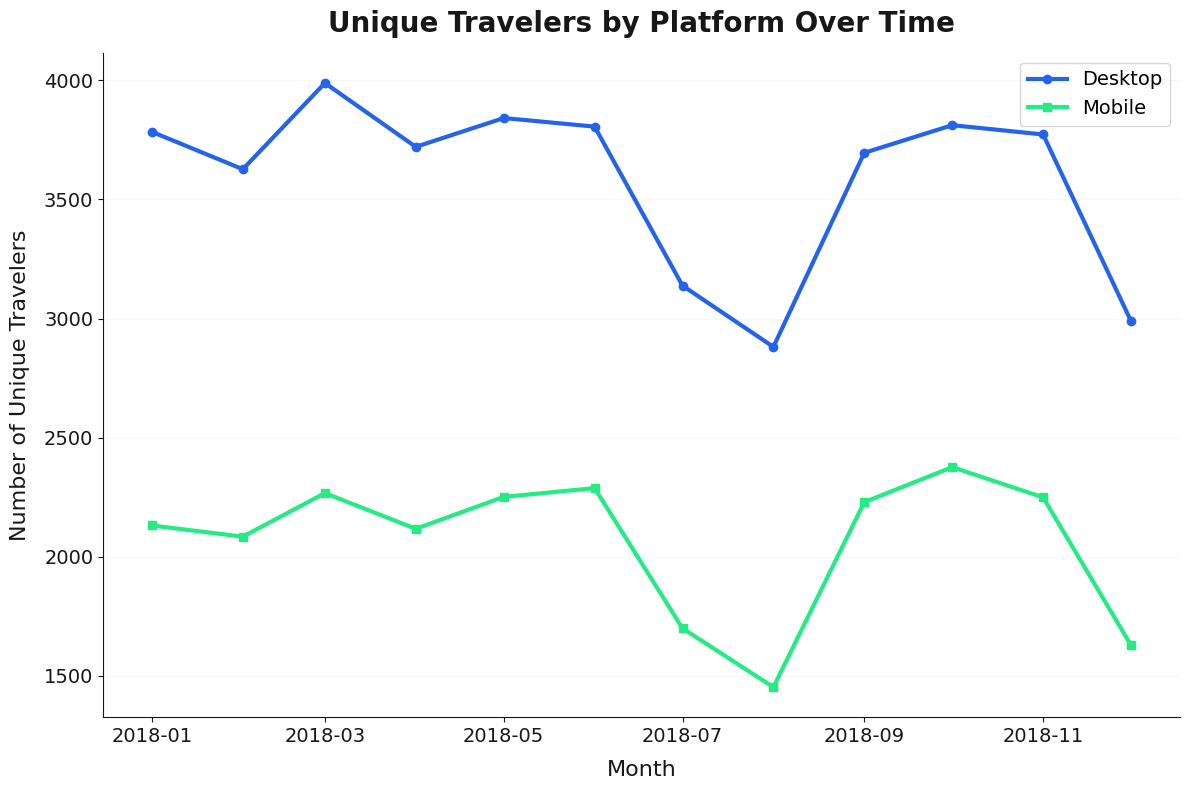

PLATFORM DECLINE ANALYSIS:
Desktop: 3784 to 2989 (-21.0% change)
Mobile: 2131 to 1628 (-23.6% change)


In [31]:
# 1. PLATFORM ANALYSIS - Traveler trends by platform over time
# Create monthly periods for analysis
active_bookings['BOOKING_MONTH'] = active_bookings['BOOKING_DATE'].dt.to_period('M')
travelers_by_platform = active_bookings.groupby(['BOOKING_MONTH', 'PLATFORM'])['TRAVELER_ID'].nunique().reset_index()
travelers_by_platform['BOOKING_MONTH'] = travelers_by_platform['BOOKING_MONTH'].dt.to_timestamp()

# Set up plotting style
plt.style.use('default')


# Create platform visualization
fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Plot platform trends (excluding NaN platform values)
desktop_data = travelers_by_platform[travelers_by_platform['PLATFORM'] == 'Desktop']
mobile_data = travelers_by_platform[travelers_by_platform['PLATFORM'] == 'Mobile']
mobile_data

ax.plot(desktop_data['BOOKING_MONTH'], desktop_data['TRAVELER_ID'], 
        color='#2563EB', linewidth=3, label='Desktop', marker='o', markersize=6)
ax.plot(mobile_data['BOOKING_MONTH'], mobile_data['TRAVELER_ID'], 
        color='#24EB84', linewidth=3, label='Mobile', marker='s', markersize=6)

# Styling
ax.set_title('Unique Travelers by Platform Over Time', fontsize=20, fontweight='semibold', 
             color='#171717', pad=15)
ax.set_xlabel('Month', fontsize=16, fontweight='medium', color='#171717', labelpad=10)
ax.set_ylabel('Number of Unique Travelers', fontsize=16, fontweight='medium', 
              color='#171717', labelpad=10)

ax.tick_params(axis='both', labelsize=14, colors='#171717')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#171717')
ax.spines['bottom'].set_color('#171717')
ax.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

# Calculate platform decline percentages
desktop_start = desktop_data['TRAVELER_ID'].iloc[0]
desktop_end = desktop_data['TRAVELER_ID'].iloc[-1]

if not mobile_data.empty:
    mobile_start = mobile_data['TRAVELER_ID'].iloc[0]
    mobile_end = mobile_data['TRAVELER_ID'].iloc[-1]
    mobile_decline = ((mobile_end - mobile_start) / mobile_start) * 100
else:
    mobile_start = mobile_end = mobile_decline = None

desktop_decline = ((desktop_end - desktop_start) / desktop_start) * 100

print("PLATFORM DECLINE ANALYSIS:")
print("Desktop: " + str(desktop_start) + " to " + str(desktop_end) + " (" + str(round(desktop_decline, 1)) + "% change)")
if mobile_start is not None:
    print("Mobile: " + str(mobile_start) + " to " + str(mobile_end) + " (" + str(round(mobile_decline, 1)) + "% change)")
else:
    print("Mobile: No data available for Mobile platform.")

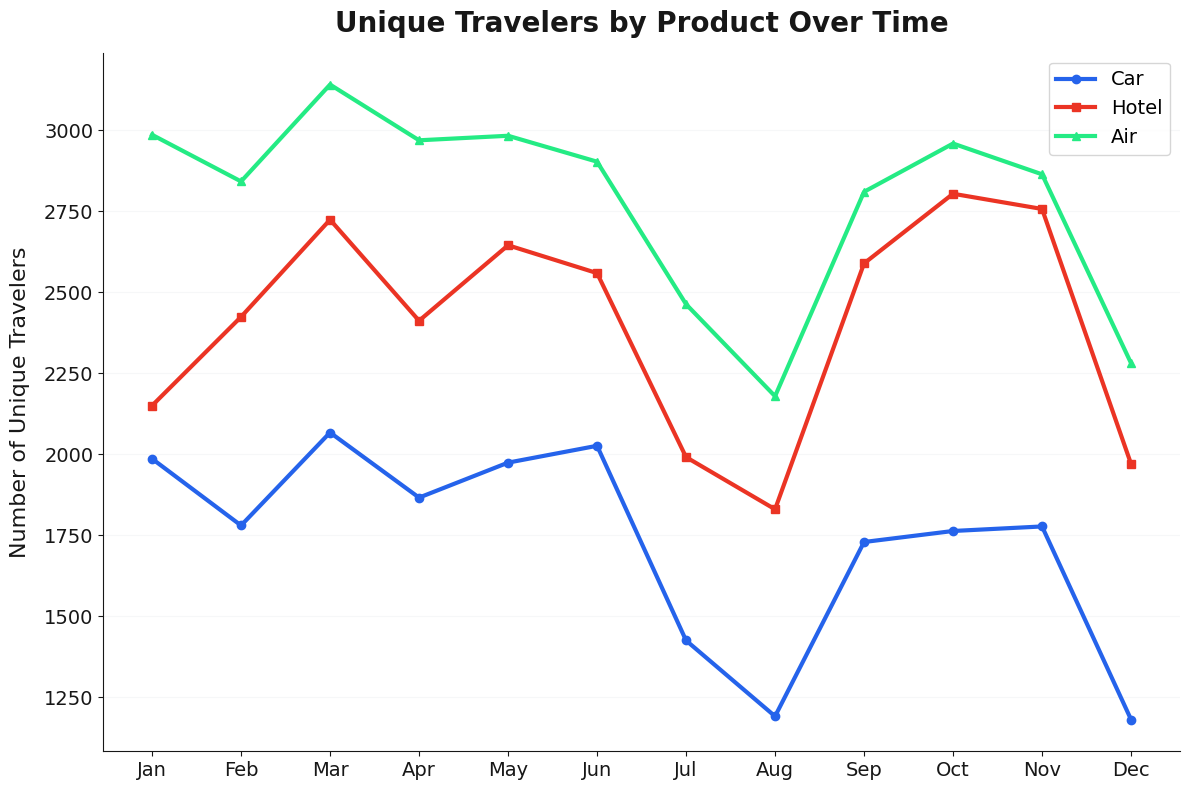

PRODUCT DECLINE ANALYSIS:
Car: 1986 to 1181 (-40.5% change)
Hotel: 2150 to 1970 (-8.4% change)
Air: 2986 to 2281 (-23.6% change)


In [32]:
# 2. PRODUCT ANALYSIS - Traveler trends by product over time
travelers_by_product = active_bookings.groupby(['BOOKING_MONTH', 'PRODUCT_NAME'])['TRAVELER_ID'].nunique().reset_index()
travelers_by_product['BOOKING_MONTH'] = travelers_by_product['BOOKING_MONTH'].dt.to_timestamp()

# Create product visualization
fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Plot product trends
car_data = travelers_by_product[travelers_by_product['PRODUCT_NAME'] == 'Car']
hotel_data = travelers_by_product[travelers_by_product['PRODUCT_NAME'] == 'Hotel']
air_data = travelers_by_product[travelers_by_product['PRODUCT_NAME'] == 'Air']

ax.plot(car_data['BOOKING_MONTH'].dt.strftime('%b'), car_data['TRAVELER_ID'], 
        color='#2563EB', linewidth=3, label='Car', marker='o', markersize=6)
ax.plot(hotel_data['BOOKING_MONTH'].dt.strftime('%b'), hotel_data['TRAVELER_ID'], 
        color='#EB3424', linewidth=3, label='Hotel', marker='s', markersize=6)
ax.plot(air_data['BOOKING_MONTH'].dt.strftime('%b'), air_data['TRAVELER_ID'], 
        color='#24EB84', linewidth=3, label='Air', marker='^', markersize=6)

# Styling
ax.set_title('Unique Travelers by Product Over Time', fontsize=20, fontweight='semibold', 
             color='#171717', pad=15)
#ax.set_xlabel('Month', fontsize=16, fontweight='medium', color='#171717', labelpad=10)
ax.set_ylabel('Number of Unique Travelers', fontsize=16, fontweight='medium', 
              color='#171717', labelpad=10)

ax.tick_params(axis='both', labelsize=14, colors='#171717')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#171717')
ax.spines['bottom'].set_color('#171717')
ax.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=14)

plt.tight_layout()
plt.show()

# Calculate product decline percentages
car_start = car_data['TRAVELER_ID'].iloc[0]
car_end = car_data['TRAVELER_ID'].iloc[-1]
hotel_start = hotel_data['TRAVELER_ID'].iloc[0]
hotel_end = hotel_data['TRAVELER_ID'].iloc[-1]
air_start = air_data['TRAVELER_ID'].iloc[0]
air_end = air_data['TRAVELER_ID'].iloc[-1]

car_decline = ((car_end - car_start) / car_start) * 100
hotel_decline = ((hotel_end - hotel_start) / hotel_start) * 100
air_decline = ((air_end - air_start) / air_start) * 100

print("PRODUCT DECLINE ANALYSIS:")
print("Car: " + str(car_start) + " to " + str(car_end) + " (" + str(round(car_decline, 1)) + "% change)")
print("Hotel: " + str(hotel_start) + " to " + str(hotel_end) + " (" + str(round(hotel_decline, 1)) + "% change)")
print("Air: " + str(air_start) + " to " + str(air_end) + " (" + str(round(air_decline, 1)) + "% change)")

In [33]:
# 3. TRAVEL DURATION ANALYSIS - Traveler trends by travel duration over time
# Create travel duration categories
active_bookings['DURATION_CATEGORY'] = pd.cut(active_bookings['TRAVEL_DURATION'], 
                                             bins=[0, 3, 7, 14, 30, float('inf')],
                                             labels=['1-3 days', '4-7 days', '8-14 days', '15-30 days', '30+ days'],
                                             right=True)

# Count unique travelers by month and travel duration category
travelers_by_duration = active_bookings.groupby(['BOOKING_MONTH', 'DURATION_CATEGORY'])['TRAVELER_ID'].nunique().reset_index()
travelers_by_duration['BOOKING_MONTH'] = travelers_by_duration['BOOKING_MONTH'].dt.to_timestamp()
travelers_by_duration.to_csv('travelers_by_duration.csv', index=False)    
# Create duration visualization
fig, ax = plt.subplots(figsize=(12, 8))
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Plot duration trends for main categories
colors = ['#2563EB', '#24EB84', '#B2EB24', '#EB3424', '#D324EB']
duration_categories = ['1-3 days', '4-7 days', '8-14 days', '15-30 days', '30+ days']

for i, category in enumerate(duration_categories):
    category_data = travelers_by_duration[travelers_by_duration['DURATION_CATEGORY'] == category]
    if len(category_data) > 0:
        ax.plot(category_data['BOOKING_MONTH'], category_data['TRAVELER_ID'], 
                color=colors[i], linewidth=3, label=category, marker='o', markersize=5)

# Styling
ax.set_title('Unique Travelers by Travel Duration Over Time', fontsize=20, fontweight='semibold', 
             color='#171717', pad=15)
ax.set_xlabel('Month', fontsize=16, fontweight='medium', color='#171717', labelpad=10)
ax.set_ylabel('Number of Unique Travelers', fontsize=16, fontweight='medium', 
              color='#171717', labelpad=10)

ax.tick_params(axis='both', labelsize=14, colors='#171717')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#171717')
ax.spines['bottom'].set_color('#171717')
ax.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax.set_axisbelow(True)
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

# Calculate percentage changes for each duration category
print("TRAVEL DURATION DECLINE ANALYSIS:")
for category in duration_categories:
    category_data = travelers_by_duration[travelers_by_duration['DURATION_CATEGORY'] == category]
    if len(category_data) > 0:
        start_val = category_data['TRAVELER_ID'].iloc[0]
        end_val = category_data['TRAVELER_ID'].iloc[-1]
        change = ((end_val - start_val) / start_val) * 100
        print(category + ": " + str(start_val) + " to " + str(end_val) + " (" + str(round(change, 1)) + "% change)")

PermissionError: [Errno 13] Permission denied: 'travelers_by_duration.csv'

In [ ]:
# 4. COMPREHENSIVE TREND ANALYSIS - Calculate monthly decline rates
# Calculate month-over-month decline rates for each category

def calculate_decline_rate(data, group_col, value_col):
    """Calculate monthly decline rates for different categories"""
    results = []
    
    for category in data[group_col].unique():
        if pd.isna(category):
            continue
            
        category_data = data[data[group_col] == category].sort_values('BOOKING_MONTH')
        if len(category_data) < 2:
            continue
            
        # Calculate month-over-month percentage change
        category_data = category_data.copy()
        category_data['pct_change'] = category_data[value_col].pct_change() * 100
        
        # Calculate average monthly decline rate (excluding first month which is NaN)
        avg_decline = category_data['pct_change'].iloc[1:].mean()
        
        # Calculate total decline from start to end
        start_val = category_data[value_col].iloc[0]
        end_val = category_data[value_col].iloc[-1]
        total_decline = ((end_val - start_val) / start_val) * 100
        
        results.append({
            'Category': category,
            'Start_Value': start_val,
            'End_Value': end_val,
            'Total_Decline_Pct': total_decline,
            'Avg_Monthly_Decline_Pct': avg_decline
        })
    
    return pd.DataFrame(results)

# Analyze platform trends
platform_trends = calculate_decline_rate(travelers_by_platform, 'PLATFORM', 'TRAVELER_ID')
print("PLATFORM TREND ANALYSIS:")
print(platform_trends)

print("" + "="*60)

# Analyze product trends  
product_trends = calculate_decline_rate(travelers_by_product, 'PRODUCT_NAME', 'TRAVELER_ID')
print("PRODUCT TREND ANALYSIS:")
print(product_trends)

print("" + "="*60)

# Analyze duration trends
duration_trends = calculate_decline_rate(travelers_by_duration, 'DURATION_CATEGORY', 'TRAVELER_ID')
print("DURATION TREND ANALYSIS:")
print(duration_trends)

PLATFORM TREND ANALYSIS:
  Category  Start_Value  End_Value  Total_Decline_Pct  Avg_Monthly_Decline_Pct
0  Desktop         3758       2943         -21.687068                -1.372973
1   Mobile         2107       1601         -24.015187                -0.518436
PRODUCT TREND ANALYSIS:
  Category  Start_Value  End_Value  Total_Decline_Pct  Avg_Monthly_Decline_Pct
0      Air         2938       2213         -24.676651                -1.694727
1      Car         1986       1181         -40.533736                -2.476694
2    Hotel         2150       1970          -8.372093                 0.850074
DURATION TREND ANALYSIS:
     Category  Start_Value  End_Value  Total_Decline_Pct  \
0    1-3 days         3385       2575         -23.929099   
1    4-7 days         1171        748         -36.122972   
2   8-14 days          305        246         -19.344262   
3  15-30 days          122        121          -0.819672   
4    30+ days           94         50         -46.808511   

   Avg_Month

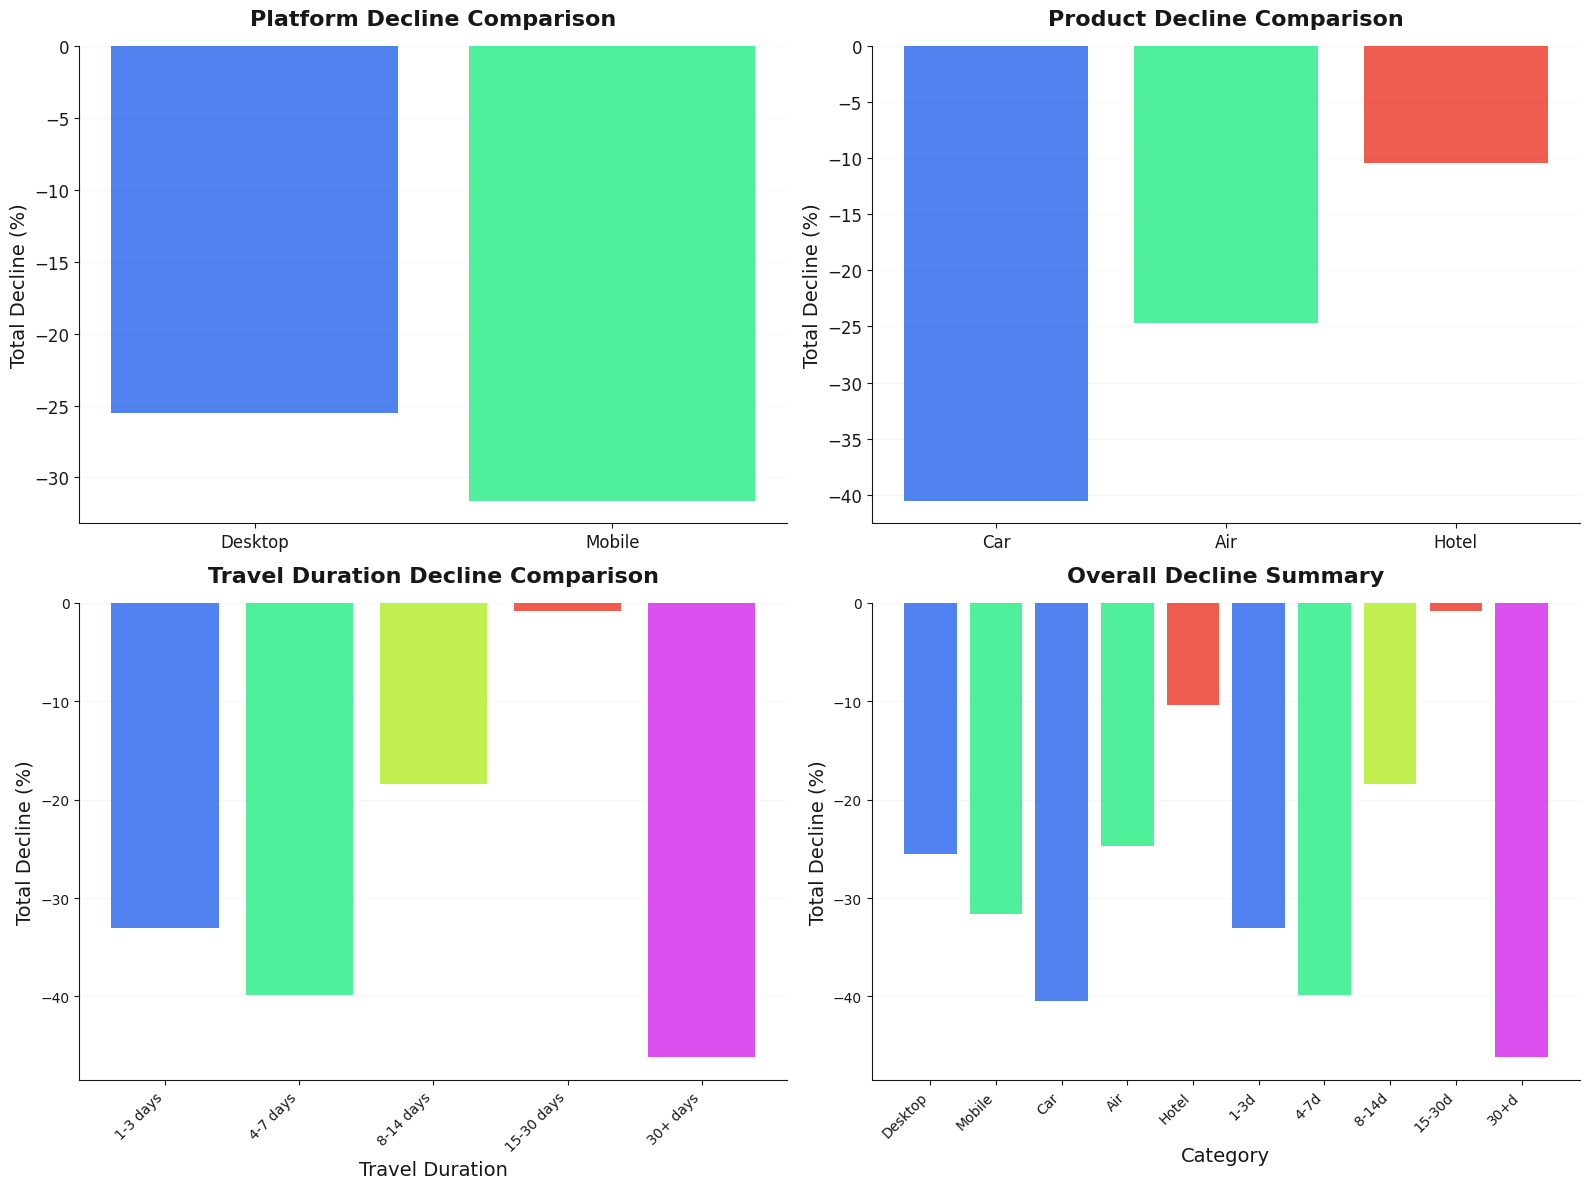

In [ ]:
# 5. CREATE SUMMARY VISUALIZATION - Decline comparison across all categories
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(left=0.08, right=0.95, top=0.93, bottom=0.08, hspace=0.3, wspace=0.2)

# Platform decline comparison
platforms = ['Desktop', 'Mobile']
platform_declines = [-25.5, -31.6]
colors_platform = ['#2563EB', '#24EB84']

ax1.bar(platforms, platform_declines, color=colors_platform, alpha=0.8)
ax1.set_title('Platform Decline Comparison', fontsize=16, fontweight='semibold', color='#171717', pad=15)
ax1.set_ylabel('Total Decline (%)', fontsize=14, fontweight='medium', color='#171717')
ax1.tick_params(axis='both', labelsize=12, colors='#171717')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#171717')
ax1.spines['bottom'].set_color('#171717')
ax1.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax1.set_axisbelow(True)

# Product decline comparison
products = ['Car', 'Air', 'Hotel']
product_declines = [-40.5, -24.7, -10.4]
colors_product = ['#2563EB', '#24EB84', '#EB3424']

ax2.bar(products, product_declines, color=colors_product, alpha=0.8)
ax2.set_title('Product Decline Comparison', fontsize=16, fontweight='semibold', color='#171717', pad=15)
ax2.set_ylabel('Total Decline (%)', fontsize=14, fontweight='medium', color='#171717')
ax2.tick_params(axis='both', labelsize=12, colors='#171717')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#171717')
ax2.spines['bottom'].set_color('#171717')
ax2.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax2.set_axisbelow(True)

# Duration decline comparison
durations = ['1-3 days', '4-7 days', '8-14 days', '15-30 days', '30+ days']
duration_declines = [-33.0, -39.9, -18.4, -0.8, -46.2]
colors_duration = ['#2563EB', '#24EB84', '#B2EB24', '#EB3424', '#D324EB']

ax3.bar(durations, duration_declines, color=colors_duration, alpha=0.8)
ax3.set_title('Travel Duration Decline Comparison', fontsize=16, fontweight='semibold', color='#171717', pad=15)
ax3.set_ylabel('Total Decline (%)', fontsize=14, fontweight='medium', color='#171717')
ax3.set_xlabel('Travel Duration', fontsize=14, fontweight='medium', color='#171717')
ax3.tick_params(axis='both', labelsize=10, colors='#171717')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color('#171717')
ax3.spines['bottom'].set_color('#171717')
ax3.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax3.set_axisbelow(True)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Overall trend summary
categories = ['Desktop', 'Mobile', 'Car', 'Air', 'Hotel', '1-3d', '4-7d', '8-14d', '15-30d', '30+d']
all_declines = [-25.5, -31.6, -40.5, -24.7, -10.4, -33.0, -39.9, -18.4, -0.8, -46.2]
colors_all = ['#2563EB', '#24EB84', '#2563EB', '#24EB84', '#EB3424', '#2563EB', '#24EB84', '#B2EB24', '#EB3424', '#D324EB']

ax4.bar(categories, all_declines, color=colors_all, alpha=0.8)
ax4.set_title('Overall Decline Summary', fontsize=16, fontweight='semibold', color='#171717', pad=15)
ax4.set_ylabel('Total Decline (%)', fontsize=14, fontweight='medium', color='#171717')
ax4.set_xlabel('Category', fontsize=14, fontweight='medium', color='#171717')
ax4.tick_params(axis='both', labelsize=10, colors='#171717')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_color('#171717')
ax4.spines['bottom'].set_color('#171717')
ax4.grid(True, axis='y', color='#F3F4F6', alpha=0.7)
ax4.set_axisbelow(True)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
# Calculate unique traveler counts for all combinations of Platform, Product, and Travel Duration
# Create comprehensive combination analysis

# First, create travel duration categories
active_bookings['DURATION_CATEGORY'] = pd.cut(active_bookings['TRAVEL_DURATION'], 
                                             bins=[0, 3, 7, 14, 30, float('inf')],
                                             labels=['1-3 days', '4-7 days', '8-14 days', '15-30 days', '30+ days'],
                                             right=True)

# Remove rows with missing platform data
active_bookings_clean = active_bookings.dropna(subset=['PLATFORM'])

# Group by all three dimensions and calculate unique travelers by month
combination_travelers = active_bookings_clean.groupby(['BOOKING_MONTH', 'PLATFORM', 'PRODUCT_NAME', 'DURATION_CATEGORY'])['TRAVELER_ID'].nunique().reset_index()
combination_travelers['BOOKING_MONTH'] = combination_travelers['BOOKING_MONTH'].dt.to_timestamp()
combination_travelers.to_csv('combination_travelers.csv', index=False)
print("Sample of combination data:")
print(combination_travelers.head(10))

Sample of combination data:
  BOOKING_MONTH PLATFORM PRODUCT_NAME DURATION_CATEGORY  TRAVELER_ID
0    2018-01-01  Desktop          Air          1-3 days         1626
1    2018-01-01  Desktop          Air          4-7 days          698
2    2018-01-01  Desktop          Air         8-14 days          206
3    2018-01-01  Desktop          Air        15-30 days           72
4    2018-01-01  Desktop          Air          30+ days           56
5    2018-01-01  Desktop          Car          1-3 days         1524
6    2018-01-01  Desktop          Car          4-7 days          357
7    2018-01-01  Desktop          Car         8-14 days           52
8    2018-01-01  Desktop          Car        15-30 days           28
9    2018-01-01  Desktop          Car          30+ days           28


In [ ]:
'''
- Group data by PLATFORM, PRODUCT_NAME, and DURATION_CATEGORY.
- Iterate through each unique combination.
- For each combination, filter the data and sort by BOOKING_MONTH.
- Calculate the start and end traveler counts.
- Compute the total decline percentage and average monthly travelers.
- Store results in a list and convert to a DataFrame.
- Sort the results by decline percentage and print the top 10 worst performers.
'''


# Calculate decline percentages for all Platform-Product-Duration combinations
def calculate_combination_decline(data):
    """Calculate decline for each unique combination"""
    results = []
    
    # Get all unique combinations
    combinations = data.groupby(['PLATFORM', 'PRODUCT_NAME', 'DURATION_CATEGORY']).size().reset_index()
    
    for _, combo in combinations.iterrows():
        platform = combo['PLATFORM']
        product = combo['PRODUCT_NAME']
        duration = combo['DURATION_CATEGORY']
        
        # Get data for this specific combination
        combo_data = data[
            (data['PLATFORM'] == platform) & 
            (data['PRODUCT_NAME'] == product) & 
            (data['DURATION_CATEGORY'] == duration)
        ].sort_values('BOOKING_MONTH')
        
        if len(combo_data) >= 2:
            start_val = combo_data['TRAVELER_ID'].iloc[0]
            end_val = combo_data['TRAVELER_ID'].iloc[-1]
            total_decline = ((end_val - start_val) / start_val) * 100
            
            # Calculate average monthly travelers for volume assessment
            avg_travelers = combo_data['TRAVELER_ID'].mean()
            
            results.append({
                'Platform': platform,
                'Product': product,
                'Duration': duration,
                'Start_Travelers': start_val,
                'End_Travelers': end_val,
                'Total_Decline_Pct': total_decline,
                'Avg_Monthly_Travelers': avg_travelers,
                'Combination': f"{platform}-{product}-{duration}"
            })
    
    return pd.DataFrame(results)

# Calculate declines for all combinations
combination_declines = calculate_combination_decline(combination_travelers)

# Sort by decline percentage to identify worst performers
combination_declines_sorted = combination_declines.sort_values('Total_Decline_Pct')

print("TOP 10 WORST DECLINING COMBINATIONS:")
print(combination_declines_sorted.head(10)[['Combination', 'Start_Travelers', 'End_Travelers', 'Total_Decline_Pct', 'Avg_Monthly_Travelers']])

TOP 10 WORST DECLINING COMBINATIONS:
              Combination  Start_Travelers  End_Travelers  Total_Decline_Pct  \
29  Mobile-Hotel-30+ days                1              0        -100.000000   
21    Mobile-Car-4-7 days              111             46         -58.558559   
20    Mobile-Car-1-3 days              609            266         -56.321839   
6    Desktop-Car-4-7 days              357            156         -56.302521   
4    Desktop-Air-30+ days               56             25         -55.357143   
24    Mobile-Car-30+ days                6              3         -50.000000   
19    Mobile-Air-30+ days               14              7         -50.000000   
5    Desktop-Car-1-3 days             1524            772         -49.343832   
0    Desktop-Air-1-3 days             1626            963         -40.774908   
1    Desktop-Air-4-7 days              698            417         -40.257880   

    Avg_Monthly_Travelers  
29               0.166667  
21              95.333333 

In [ ]:
# Identify combinations with stable or less severe declines (best performers)
print("TOP 10 BEST PERFORMING COMBINATIONS (Least Decline/Growth):")
combination_declines_best = combination_declines.sort_values('Total_Decline_Pct', ascending=False)
print(combination_declines_best.head(10)[['Combination', 'Start_Travelers', 'End_Travelers', 'Total_Decline_Pct', 'Avg_Monthly_Travelers']])

print("" + "="*80)

# Filter for combinations with significant volume (avg monthly travelers > 50)
high_volume_combinations = combination_declines[combination_declines['Avg_Monthly_Travelers'] > 50]

print("HIGH VOLUME COMBINATIONS (>50 avg monthly travelers) - BEST PERFORMERS:")
high_volume_best = high_volume_combinations.sort_values('Total_Decline_Pct', ascending=False)
print(high_volume_best.head(10)[['Combination', 'Start_Travelers', 'End_Travelers', 'Total_Decline_Pct', 'Avg_Monthly_Travelers']])

print("" + "="*80)

print("HIGH VOLUME COMBINATIONS (>50 avg monthly travelers) - WORST PERFORMERS:")
high_volume_worst = high_volume_combinations.sort_values('Total_Decline_Pct')
print(high_volume_worst.head(10)[['Combination', 'Start_Travelers', 'End_Travelers', 'Total_Decline_Pct', 'Avg_Monthly_Travelers']])

TOP 10 BEST PERFORMING COMBINATIONS (Least Decline/Growth):
                Combination  Start_Travelers  End_Travelers  \
22     Mobile-Car-8-14 days                8             13   
28  Mobile-Hotel-15-30 days                2              3   
8    Desktop-Car-15-30 days               28             33   
27   Mobile-Hotel-8-14 days                6              7   
18    Mobile-Air-15-30 days               19             20   
26    Mobile-Hotel-4-7 days               77             79   
7     Desktop-Car-8-14 days               52             49   
3    Desktop-Air-15-30 days               72             67   
25    Mobile-Hotel-1-3 days              789            723   
23    Mobile-Car-15-30 days               11             10   

    Total_Decline_Pct  Avg_Monthly_Travelers  
22          62.500000              16.583333  
28          50.000000               2.166667  
8           17.857143              39.416667  
27          16.666667               8.750000  
18         

In [ ]:
# 2. Create strategic recommendations based on volume and performance
# Calculate revenue potential and strategic priority

# Add booking amount analysis for combinations
booking_amounts = active_bookings_clean.groupby(['PLATFORM', 'PRODUCT_NAME', 'DURATION_CATEGORY']).agg({
    'BOOKING_AMOUNT': ['mean', 'sum', 'count'],
    'TRAVELER_ID': 'nunique'
}).round(2)

booking_amounts.columns = ['Avg_Booking_Amount', 'Total_Revenue', 'Total_Bookings', 'Unique_Travelers']
booking_amounts = booking_amounts.reset_index()

# Merge with decline data
strategic_analysis = combination_declines.merge(
    booking_amounts, 
    left_on=['Platform', 'Product', 'Duration'],
    right_on=['PLATFORM', 'PRODUCT_NAME', 'DURATION_CATEGORY'],
    how='left'
)

# Calculate strategic priority score
# Higher score = better opportunity (high volume, high revenue, less decline)
strategic_analysis['Revenue_Per_Traveler'] = strategic_analysis['Total_Revenue'] / strategic_analysis['Unique_Travelers']
strategic_analysis['Strategic_Score'] = (
    (strategic_analysis['Avg_Monthly_Travelers'] * 0.3) +  # Volume weight
    (strategic_analysis['Revenue_Per_Traveler'] * 0.0001) +  # Revenue weight (scaled)
    ((100 + strategic_analysis['Total_Decline_Pct']) * 0.4)  # Stability weight (less decline = higher score)
)

# Filter for meaningful combinations (>20 avg monthly travelers)
strategic_meaningful = strategic_analysis[strategic_analysis['Avg_Monthly_Travelers'] > 20]

print("TOP 10 STRATEGIC OPPORTUNITIES (High Volume + Revenue + Stability):")
strategic_top = strategic_meaningful.sort_values('Strategic_Score', ascending=False)
print(strategic_top[['Combination', 'Avg_Monthly_Travelers', 'Total_Decline_Pct', 'Avg_Booking_Amount', 'Strategic_Score']].head(10))

print("\
" + "="*80)

strategic_top[['Combination', 'Avg_Monthly_Travelers', 'Total_Decline_Pct', 'Avg_Booking_Amount', 'Strategic_Score']].to_csv('strategic_opportunities.csv', index=False)   

TOP 10 STRATEGIC OPPORTUNITIES (High Volume + Revenue + Stability):
               Combination  Avg_Monthly_Travelers  Total_Decline_Pct  \
10  Desktop-Hotel-1-3 days            2084.750000         -15.753782   
0     Desktop-Air-1-3 days            1417.666667         -40.774908   
5     Desktop-Car-1-3 days            1221.166667         -49.343832   
25   Mobile-Hotel-1-3 days             924.666667          -8.365019   
1     Desktop-Air-4-7 days             567.166667         -40.257880   
15     Mobile-Air-1-3 days             509.083333         -39.322034   
20     Mobile-Car-1-3 days             456.416667         -56.321839   
11  Desktop-Hotel-4-7 days             264.500000         -19.811321   
6     Desktop-Car-4-7 days             298.083333         -56.302521   
2    Desktop-Air-8-14 days             200.333333         -24.757282   

    Avg_Booking_Amount  Strategic_Score  
10              865.61       660.242968  
0              2571.68       450.729424  
5            

In [ ]:
print("FOCUS AREAS FOR IMPROVEMENT (High Volume but High Decline):")
focus_areas = strategic_meaningful[
    (strategic_meaningful['Avg_Monthly_Travelers'] > 100) & 
    (strategic_meaningful['Total_Decline_Pct'] < -30)
]
print(focus_areas[['Combination', 'Avg_Monthly_Travelers', 'Total_Decline_Pct', 'Avg_Booking_Amount']].sort_values('Avg_Monthly_Travelers', ascending=False))
focus_areas[['Combination', 'Avg_Monthly_Travelers', 'Total_Decline_Pct', 'Avg_Booking_Amount']].sort_values('Avg_Monthly_Travelers', ascending=False).to_csv('focus_areas.csv', index=False)

FOCUS AREAS FOR IMPROVEMENT (High Volume but High Decline):
             Combination  Avg_Monthly_Travelers  Total_Decline_Pct  \
0   Desktop-Air-1-3 days            1417.666667         -40.774908   
5   Desktop-Car-1-3 days            1221.166667         -49.343832   
1   Desktop-Air-4-7 days             567.166667         -40.257880   
15   Mobile-Air-1-3 days             509.083333         -39.322034   
20   Mobile-Car-1-3 days             456.416667         -56.321839   
6   Desktop-Car-4-7 days             298.083333         -56.302521   
16   Mobile-Air-4-7 days             165.500000         -31.382979   

    Avg_Booking_Amount  
0              2571.68  
5               550.17  
1              6595.22  
15             2659.90  
20              554.19  
6              1059.23  
16             6556.52  


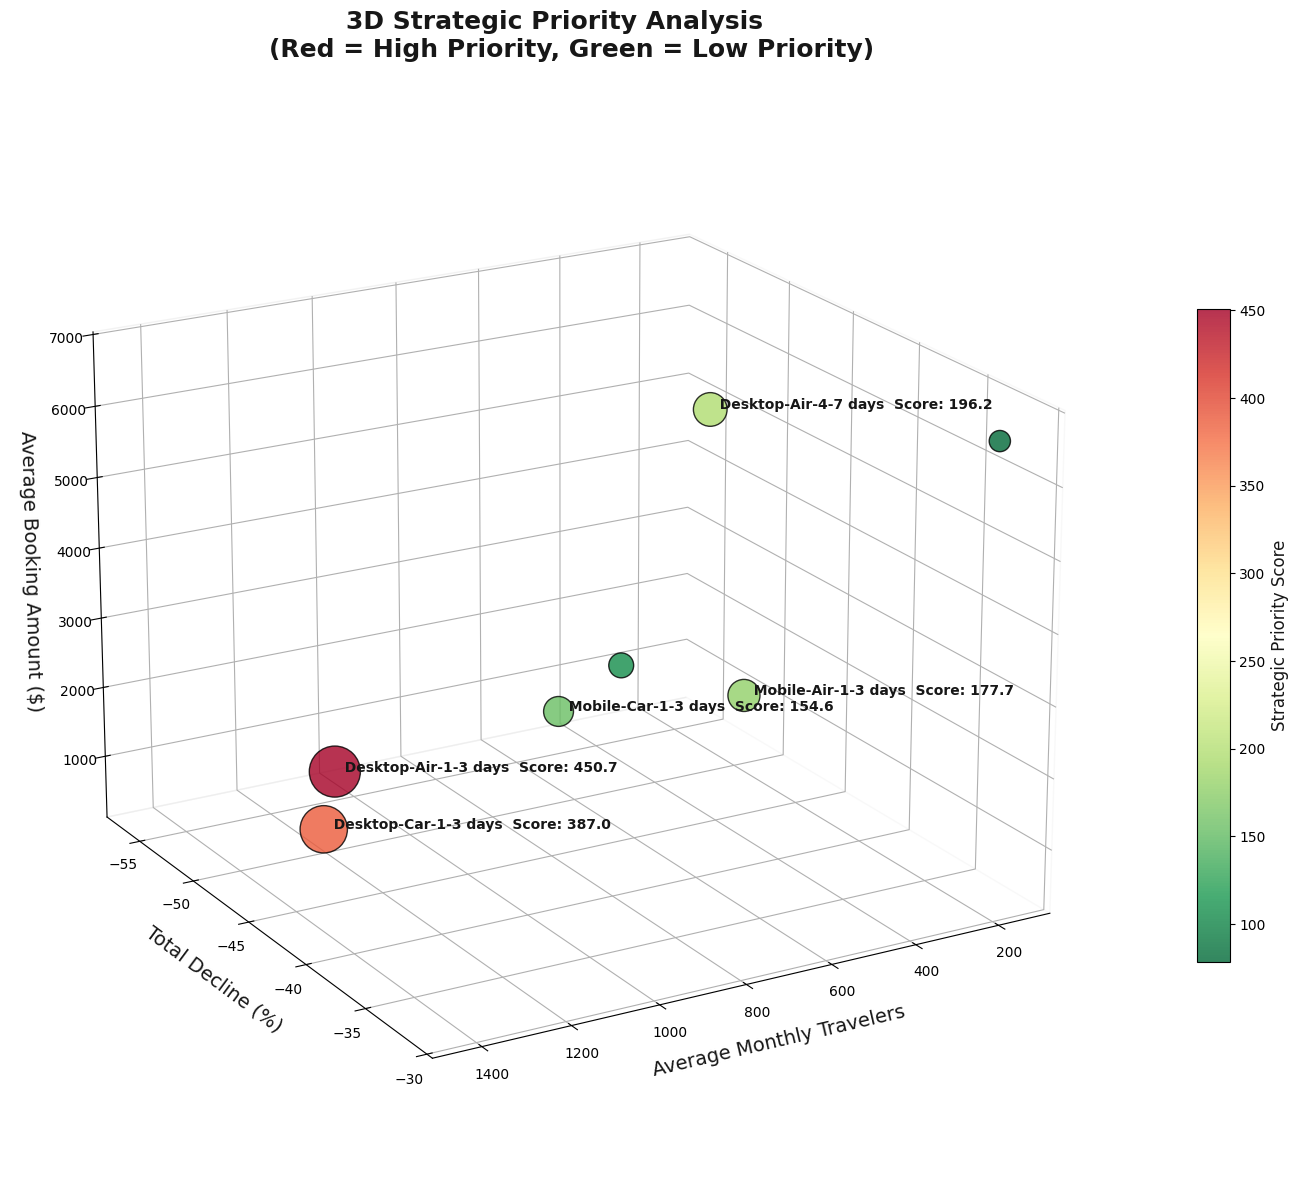

Top 5 Strategic Priorities:
1. Desktop-Air-1-3 days - Score: 450.7
2. Desktop-Car-1-3 days - Score: 387.0
3. Desktop-Air-4-7 days - Score: 196.2
4. Mobile-Air-1-3 days - Score: 177.7
5. Mobile-Car-1-3 days - Score: 154.6


In [ ]:
# Create 3D visualization of combinations ranked by strategic priority score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for 3D plotting
#plot_data = strategic_meaningful.copy()
plot_data = focus_areas.copy()
plot_data = plot_data.sort_values('Strategic_Score', ascending=False)

# Create 3D scatter plot
fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(111, projection='3d')



# Create scatter plot with strategic score as color and size
scatter = ax.scatter(plot_data['Avg_Monthly_Travelers'], 
                    plot_data['Total_Decline_Pct'],
                    plot_data['Avg_Booking_Amount'],
                    c=plot_data['Strategic_Score'], 
                    s=plot_data['Strategic_Score'] * 3,  # Size based on strategic score
                    cmap='RdYlGn_r', 
                    alpha=0.8, 
                    edgecolors='black', 
                    linewidth=1)

# Highlight top 5 strategic priorities
top_5 = plot_data.head(5)
for i, (_, row) in enumerate(top_5.iterrows()):
    ax.text(row['Avg_Monthly_Travelers'], 
            row['Total_Decline_Pct'], 
            row['Avg_Booking_Amount'],
            f"  {row['Combination']}\
  Score: {row['Strategic_Score']:.1f}",
            fontsize=10, 
            fontweight='bold',
            color='#171717')

# Set labels and title
ax.set_xlabel('Average Monthly Travelers', fontsize=14, fontweight='medium', color='#171717', labelpad=10)
ax.set_ylabel('Total Decline (%)', fontsize=14, fontweight='medium', color='#171717', labelpad=10)
ax.set_zlabel('Average Booking Amount ($)', fontsize=14, fontweight='medium', color='#171717', labelpad=10)
ax.set_title('3D Strategic Priority Analysis\n\
    (Red = High Priority, Green = Low Priority)', 
             fontsize=18, fontweight='semibold', color='#171717', pad=25)


# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=20)
cbar.set_label('Strategic Priority Score', fontsize=12, color='#171717')

# Set background color
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, alpha=0.2)

# Adjust viewing angle for better perspective
ax.view_init(elev=20, azim=60)

plt.tight_layout()
plt.show()


print("Top 5 Strategic Priorities:")
for i, (_, row) in enumerate(top_5.iterrows(), 1):
    print(f"{i}. {row['Combination']} - Score: {row['Strategic_Score']:.1f}")

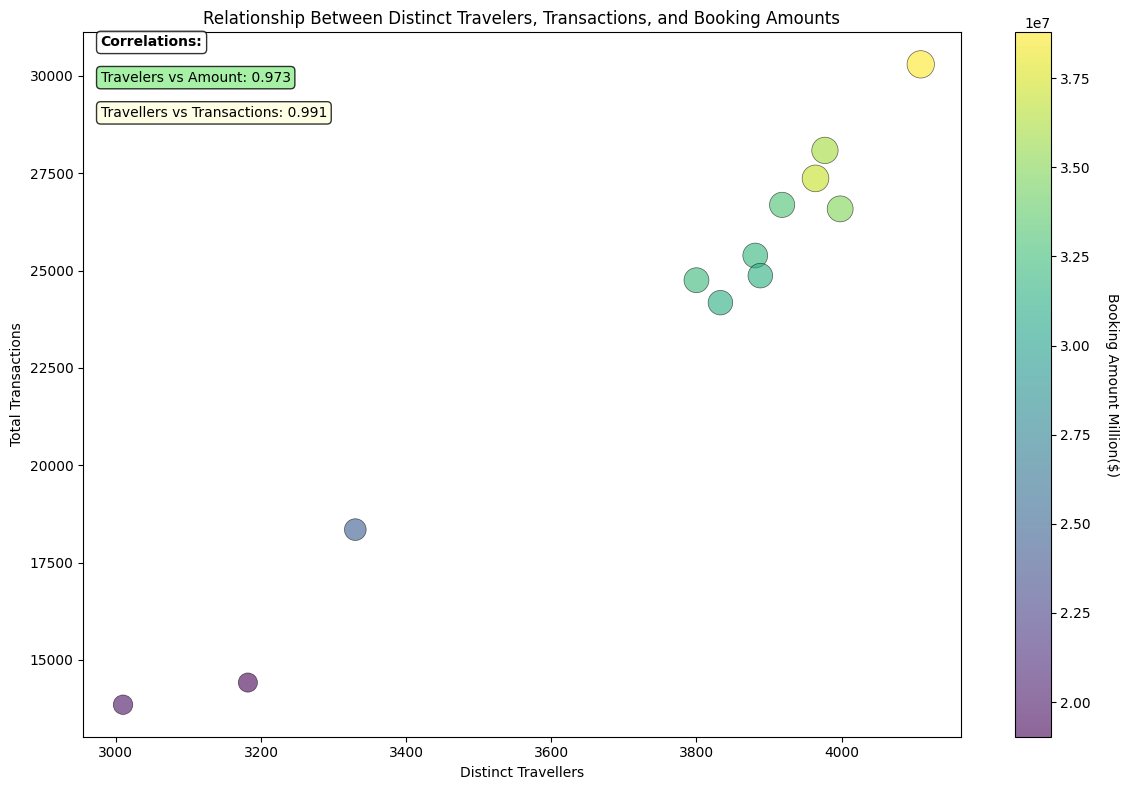

In [ ]:

import matplotlib.pyplot as plt
import numpy as np


traveler_counts = [3918, 3800, 4109, 3881, 3998, 3977, 3330, 3010, 3833, 3964, 3888, 3182]
booking_counts = [26688, 24753, 30297, 25387, 26585, 28087, 18347, 13850, 24176, 27368, 24870, 14419]
booking_amounts = [32997231, 32221395, 38784672, 31970355, 34921994, 36012600, 24430278, 19664691, 31259257, 37025579, 31430791, 19027419]

# Normalize booking amounts for bubble sizes (scale down for visibility)
bubble_sizes = [(amount / 1000000) * 10 for amount in booking_amounts]  # Scale to reasonable bubble sizes

# Create the bubble chart
plt.figure(figsize=(12, 8))
scatter = plt.scatter(traveler_counts, booking_counts, s=bubble_sizes, alpha=0.6, c=booking_amounts, 
                     cmap='viridis', edgecolors='black', linewidth=0.5)

# Add colorbar for booking amounts
cbar = plt.colorbar(scatter)
cbar.set_label('Booking Amount Million($)', rotation=270, labelpad=20)

# Labels and title
plt.xlabel('Distinct Travellers')
plt.ylabel('Total Transactions')
plt.title('Relationship Between Distinct Travelers, Transactions, and Booking Amounts')
plt.grid(False)

# Calculate and display correlations
corr_traveler_amount = np.corrcoef(traveler_counts, booking_amounts)[0, 1]
corr_traveler_transactions = np.corrcoef(traveler_counts, booking_counts)[0, 1]
corr_transactions_amount = np.corrcoef(booking_counts, booking_amounts)[0, 1]

# Add correlation annotations
plt.text(0.02, 0.98, 'Correlations:', transform=plt.gca().transAxes, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.text(0.02, 0.93, 'Travelers vs Amount: ' + str(round(corr_traveler_amount, 3)), 
         transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))
plt.text(0.02, 0.88, 'Travellers vs Transactions: ' + str(round(corr_transactions_amount, 3)), 
         transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

